# Default Rate Forecasting — Institutional Loan Universe

**Objective:** Forecast the LTM (Last 12-Month) default rate in the institutional loan market one year ahead.

Using data as of **9/30/2020**, predict the default rate at **9/30/2021**.


Student Name: Aarya Denisk Dantara 
Student ID: A00055259

## 1. Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm
from scipy import stats
from sklearn.metrics import mean_squared_error, mean_absolute_error

## 2. Data Import

Load the dataset and set the Date as index.

In [2]:
df = pd.read_excel('data.xlsx', parse_dates=['Date'])
df = df.set_index('Date').sort_index()
df.head()

,Default Rate,Index 1,Flows 1,Flows 2,Index 2,Issuance 1,Issuance 2,Rating,Distress,Bank Lending,Migration,Rate 1,Flows 3,Flows 4,Issuance 3,Issuance 4,Index 3,Fed,CBs
Date,,,,,,,,,,,,,,,,,,,
2003-08-31,0.028958,8.3,7.322046,-0.402876,18.63,0.099278,0.022891,13.021838,0.0201,3.4,-1.713236,-0.308216,NaN,NaN,NaN,NaN,126.55,0.744018,2.879388
2003-09-30,0.030651,8.4,10.176246,0.615243,22.72,0.134275,0.022761,13.036761,0.0190,3.4,-2.482936,-0.254574,NaN,NaN,NaN,NaN,116.69,0.741193,3.064331
2003-10-31,0.023121,8.0,8.656090,1.428545,16.10,0.131341,0.021702,13.073974,0.0313,0.0,-2.889539,-0.305483,NaN,NaN,NaN,NaN,118.76,0.741193,3.064331
2003-11-30,0.022989,8.0,8.140603,1.524404,16.32,0.174195,0.026035,13.101163,0.0207,0.0,-2.429453,-0.094320,NaN,NaN,NaN,NaN,104.91,0.741193,3.064331
2003-12-31,0.022814,7.6,10.261504,1.090396,18.31,0.088233,0.022642,13.096769,0.0122,0.0,-2.252134,-0.093181,NaN,NaN,NaN,NaN,117.91,0.771551,3.222516


In [3]:
print('Shape:', df.shape)
print('Date range:', df.index.min().date(), 'to', df.index.max().date())
print('\nMissing values:')
print(df.isnull().sum()[df.isnull().sum() > 0])

Shape: (206, 19)
Date range: 2003-08-31 to 2020-09-30

Missing values:
Flows 3       11
Flows 4       11
Issuance 3    11
Issuance 4    11
dtype: int64


## 3. Column Interpretation

The columns are anonymised. Based on their ranges and behaviour during the 2008 crisis and COVID-19:

| Column | Likely Meaning |
|---|---|
| Default Rate | LTM Default Rate — our **target variable** |
| Index 1 | Unemployment Rate (%) |
| Flows 1 / 2 | Loan Fund Inflows / Outflows (%) |
| Index 2 | Credit Spread — widens sharply in crises |
| Issuance 1 / 2 | Loan Issuance Volumes |
| Rating | Loan Market Size (log scale) |
| Distress | Distressed Loan Ratio |
| Bank Lending | Senior Loan Officer Survey (tightening standards) |
| Migration | Rating Downgrade Rate |
| Rate 1 | Benchmark Rate / Spread |
| Flows 3 / 4 | Institutional / Retail Loan Flows (from Jul 2004) |
| Issuance 3 / 4 | CLO / BSL Issuance (from Jul 2004) |
| Index 3 | VIX — Market Volatility Index |
| Fed | Fed Balance Sheet ($bn) |
| CBs | Central Bank Policy Rate Index |


## 4. Exploratory Data Analysis

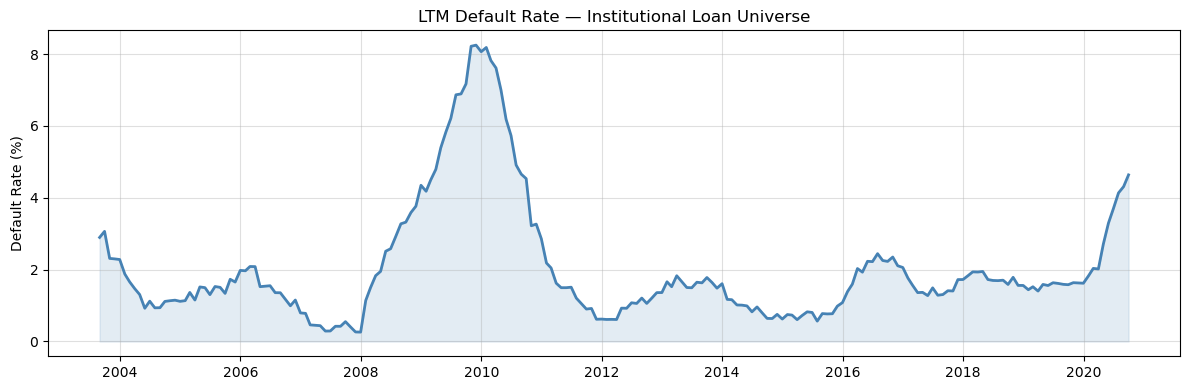

Max: 8.25% in Nov 2009
Min: 0.26% in Dec 2007


In [4]:
# Default rate over time
plt.figure(figsize=(12, 4))
plt.plot(df.index, df['Default Rate'] * 100, color='steelblue', linewidth=2)
plt.fill_between(df.index, df['Default Rate'] * 100, alpha=0.15, color='steelblue')
plt.title('LTM Default Rate — Institutional Loan Universe')
plt.ylabel('Default Rate (%)')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

print(f"Max: {df['Default Rate'].max()*100:.2f}% in {df['Default Rate'].idxmax().strftime('%b %Y')}")
print(f"Min: {df['Default Rate'].min()*100:.2f}% in {df['Default Rate'].idxmin().strftime('%b %Y')}")

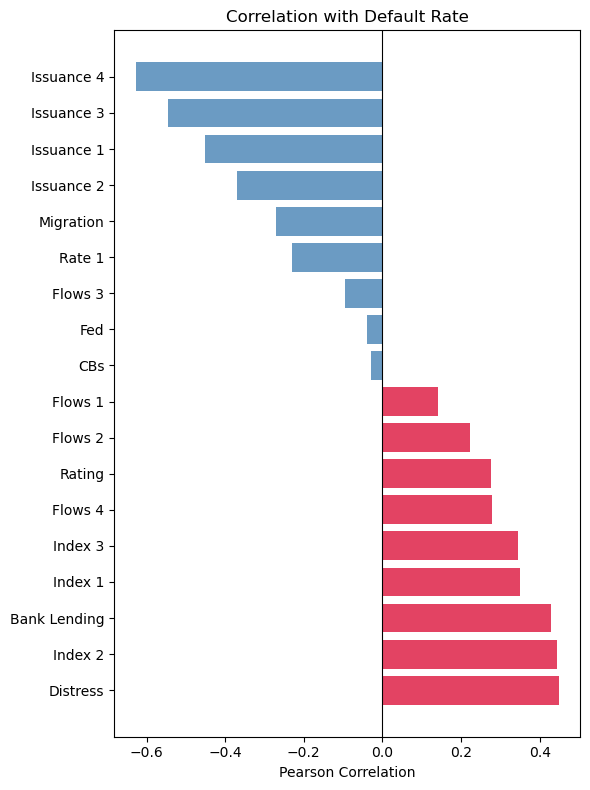

In [5]:
# Correlation with default rate
corr = df.corr()[['Default Rate']].drop('Default Rate').sort_values('Default Rate', ascending=False)

plt.figure(figsize=(6, 8))
colors = ['crimson' if v > 0 else 'steelblue' for v in corr['Default Rate']]
plt.barh(corr.index, corr['Default Rate'], color=colors, alpha=0.8)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Correlation with Default Rate')
plt.xlabel('Pearson Correlation')
plt.tight_layout()
plt.show()

**Observations:**
- `Index 2` (Credit Spread) and `Distress` have the strongest positive correlation — as these rise, defaults rise.
- `Flows 1`, `Bank Lending`, `Migration` show strong negative correlation.


## 5. Variable Selection & Feature Engineering

We select variables based on:
1. **Economic logic** — does the variable causally relate to default risk?
2. **Correlation** — does the empirical relationship hold in the data?
3. **Lead/lag structure** — we lag variables so they are observable *before* the default event (avoids look-ahead bias)

**Selected features:**

| Feature | Lag | Reason |
|---|---|---|
| Index 2 (Credit Spread) | 0 | Best real-time default signal — widening spreads reflect rising default risk |
| Distress (Distressed Ratio) | 6 months | Distressed loans today default 6–12 months later |
| Bank Lending (Tightening) | 6 months | Tighter credit standards restrict refinancing, triggering defaults |
| Index 1 (Unemployment) | 6 months | Rising unemployment impairs debt serviceability |
| Migration (Downgrade Rate) | 3 months | Downgrades closely precede defaults |
| Index 3 (VIX) | 0 | Market stress is coincident with default spikes |


In [6]:
data = df.copy()

# Apply lags
data['spread']      = data['Index 2']               # 0-month lag
data['distress_l6'] = data['Distress'].shift(6)      # 6-month lag
data['lending_l6']  = data['Bank Lending'].shift(6)  # 6-month lag
data['unemp_l6']    = data['Index 1'].shift(6)       # 6-month lag
data['migrate_l3']  = data['Migration'].shift(3)     # 3-month lag
data['vix']         = data['Index 3']                # 0-month lag

features = ['spread', 'distress_l6', 'lending_l6', 'unemp_l6', 'migrate_l3', 'vix']

# Log-transform target to stabilise variance and ensure positivity
data['log_default'] = np.log(data['Default Rate'])

# Drop NaN rows introduced by lagging
model_data = data[['log_default', 'Default Rate'] + features].dropna()

print(f"Model dataset: {model_data.shape[0]} obs  "
      f"({model_data.index.min().date()} to {model_data.index.max().date()})")
model_data.head()

Model dataset: 200 obs  (2004-02-29 to 2020-09-30)


,log_default,Default Rate,spread,distress_l6,lending_l6,unemp_l6,migrate_l3,vix
Date,,,,,,,,
2004-02-29,-4.098041,0.016605,14.55,0.0201,3.4,8.3,-2.429453,90.14
2004-03-31,-4.219508,0.014706,16.74,0.0190,3.4,8.4,-2.252134,105.92
2004-04-30,-4.338224,0.013060,17.19,0.0313,0.0,8.0,-1.672175,122.93
2004-05-31,-4.683981,0.009242,15.50,0.0207,0.0,8.0,-1.474790,106.12
2004-06-30,-4.490507,0.011215,14.34,0.0122,0.0,7.6,-1.173643,93.91


## 6. Stationarity Testing (ADF Test)

The ADF test checks for a unit root (non-stationarity).

- **H₀:** Series has a unit root (non-stationary)
- p-value < 0.05 → reject H₀ → series is **stationary**
- p-value ≥ 0.05 → series is **non-stationary** → take first difference


In [7]:
def adf_test(series, name):
    result = adfuller(series.dropna(), autolag='AIC')
    pval = result[1]
    status = "Stationary" if pval < 0.05 else "Non-stationary"
    print(f"{name:20s}  p-value: {pval:.4f}  →  {status}")

print("ADF Test — Levels")
print("-" * 55)
for col in ['log_default'] + features:
    adf_test(model_data[col], col)

ADF Test — Levels
-------------------------------------------------------
log_default           p-value: 0.0948  →  Non-stationary
spread                p-value: 0.0057  →  Stationary
distress_l6           p-value: 0.0087  →  Stationary
lending_l6            p-value: 0.0174  →  Stationary
unemp_l6              p-value: 0.8707  →  Non-stationary
migrate_l3            p-value: 0.1202  →  Non-stationary
vix                   p-value: 0.0546  →  Non-stationary


In [8]:
print("ADF Test — First Differences")
print("-" * 55)
for col in ['log_default'] + features:
    adf_test(model_data[col].diff().dropna(), f"Δ{col}")

ADF Test — First Differences
-------------------------------------------------------
Δlog_default          p-value: 0.0007  →  Stationary
Δspread               p-value: 0.0000  →  Stationary
Δdistress_l6          p-value: 0.0000  →  Stationary
Δlending_l6           p-value: 0.0000  →  Stationary
Δunemp_l6             p-value: 0.0010  →  Stationary
Δmigrate_l3           p-value: 0.0000  →  Stationary
Δvix                  p-value: 0.0000  →  Stationary


`log_default` is I(1) — non-stationary in levels, stationary after first differencing. This means we set **d=1** in our ARIMA models. The exogenous features are stationary in levels.

## 7. ACF and PACF

These plots help us identify the AR(p) and MA(q) orders for our model.

- **ACF** — cuts off at lag q → suggests MA(q)
- **PACF** — cuts off at lag p → suggests AR(p)


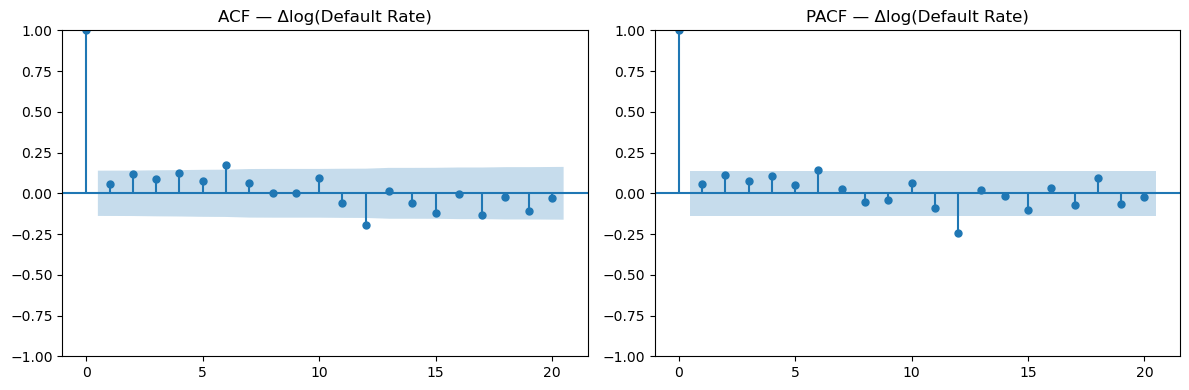

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(model_data['log_default'].diff().dropna(), lags=20, ax=axes[0])
plot_pacf(model_data['log_default'].diff().dropna(), lags=20, ax=axes[1])
axes[0].set_title('ACF — Δlog(Default Rate)')
axes[1].set_title('PACF — Δlog(Default Rate)')
plt.tight_layout()
plt.show()

## 8. Train / Test Split

Time series must be split **chronologically** — never randomly (random splitting leaks future information into training).

We hold out the last **24 months** as our test set.


In [10]:
CUTOFF = '2018-09-30'
train = model_data[model_data.index <= CUTOFF]
test  = model_data[model_data.index >  CUTOFF]

print(f"Train: {train.index.min().date()} to {train.index.max().date()}  ({len(train)} obs)")
print(f"Test:  {test.index.min().date()}  to {test.index.max().date()}   ({len(test)} obs)")

y_train, X_train = train['log_default'], train[features]
y_test,  X_test  = test['log_default'],  test[features]

Train: 2004-02-29 to 2018-09-30  (176 obs)
Test:  2018-10-31  to 2020-09-30   (24 obs)


## 9. Model 1 — OLS Regression (Baseline)

A simple linear regression with our lagged features. This is the benchmark — we want our time-series models to beat it.


In [11]:
ols_model = sm.OLS(y_train, sm.add_constant(X_train)).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:            log_default   R-squared:                       0.471
Model:                            OLS   Adj. R-squared:                  0.452
Method:                 Least Squares   F-statistic:                     25.05
Date:                Thu, 09 Apr 2026   Prob (F-statistic):           3.76e-21
Time:                        15:31:52   Log-Likelihood:                -136.88
No. Observations:                 176   AIC:                             287.8
Df Residuals:                     169   BIC:                             310.0
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -4.4227      0.209    -21.138      

In [12]:
ols_pred = np.exp(ols_model.predict(sm.add_constant(X_test)))
actual   = np.exp(y_test)

ols_rmse = np.sqrt(mean_squared_error(actual, ols_pred))
ols_mae  = mean_absolute_error(actual, ols_pred)
print(f"OLS — RMSE: {ols_rmse*100:.4f} pp   MAE: {ols_mae*100:.4f} pp")

OLS — RMSE: 1.3588 pp   MAE: 0.9915 pp


## 10. Model 2 — ARIMAX

**ARIMAX(p, d, q)** — ARIMA with eXogenous inputs.

- **AR(p):** Uses p lagged values of the series
- **I(d=1):** First-differencing because log-default is I(1)
- **MA(q):** Uses q lagged forecast errors
- **X:** Our macro feature block

We grid-search over p, q ∈ {0, 1, 2} and select by BIC.


In [13]:
# ACF/PACF on the differenced series told us p=1, q=1 is a good starting point
# d=1 because log_default is I(1)
best_p, best_q = 1, 1
print(f"Using ARIMA({best_p}, 1, {best_q})")

Using ARIMA(1, 1, 1)


In [14]:
# Fit ARIMAX(1,1,1) with the macro exogenous block
arimax_model = SARIMAX(y_train,
                       exog=X_train,
                       order=(best_p, 1, best_q),
                       seasonal_order=(0, 0, 0, 0))

arimax_fit = arimax_model.fit(disp=False)
print(arimax_fit.summary())

                               SARIMAX Results                                
Dep. Variable:            log_default   No. Observations:                  176
Model:               SARIMAX(1, 1, 1)   Log Likelihood                  45.193
Date:                Thu, 09 Apr 2026   AIC                            -72.385
Time:                        15:31:52   BIC                            -43.902
Sample:                    02-29-2004   HQIC                           -60.832
                         - 09-30-2018                                         
Covariance Type:                  opg                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
spread         -0.0004      0.005     -0.094      0.925      -0.010       0.009
distress_l6    -0.2266      1.149     -0.197      0.844      -2.478       2.025
lending_l6      0.0045      0.004      1.225    

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [15]:
arimax_pred = np.exp(arimax_fit.forecast(steps=len(test), exog=X_test))

arimax_rmse = np.sqrt(mean_squared_error(actual, arimax_pred))
arimax_mae  = mean_absolute_error(actual, arimax_pred)
print(f"ARIMAX — RMSE: {arimax_rmse*100:.4f} pp   MAE: {arimax_mae*100:.4f} pp")

ARIMAX — RMSE: 1.1180 pp   MAE: 0.6176 pp


### Residual Diagnostics

In [16]:
# Ljung-Box test — H0: no autocorrelation in residuals
lb = acorr_ljungbox(arimax_fit.resid.dropna(), lags=[10, 20], return_df=True)
print(lb)

     lb_stat  lb_pvalue
10  1.465288   0.999039
20  5.924700   0.998995


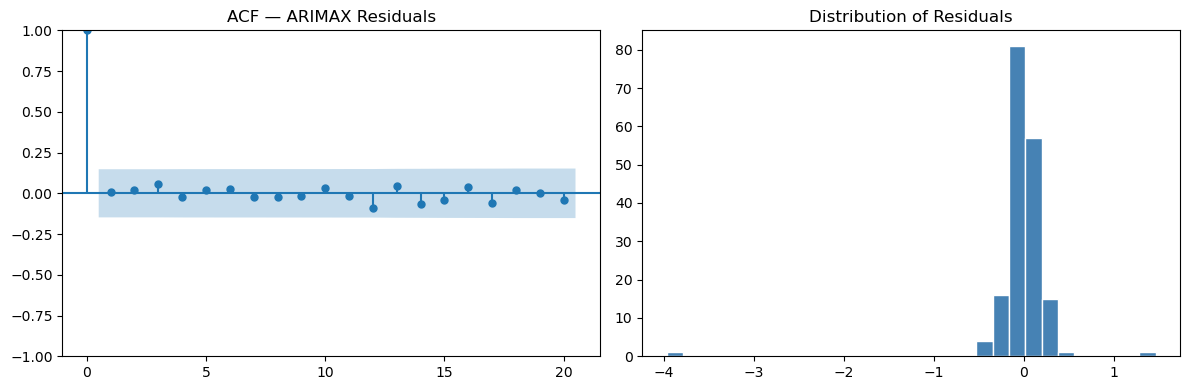

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(arimax_fit.resid.dropna(), lags=20, ax=axes[0])
axes[0].set_title('ACF — ARIMAX Residuals')
axes[1].hist(arimax_fit.resid.dropna(), bins=30, color='steelblue', edgecolor='white')
axes[1].set_title('Distribution of Residuals')
plt.tight_layout()
plt.show()

## 11. Model 3 — SARIMAX

**SARIMAX** adds a seasonal component on top of ARIMAX. We test seasonal period = 12 (annual) to capture any calendar effects in default rates.


In [18]:
# Fit SARIMAX — adds seasonal (12) component on top of ARIMAX
sarimax_model = SARIMAX(y_train,
                        exog=X_train,
                        order=(best_p, 1, best_q),
                        seasonal_order=(1, 0, 1, 12))

sarimax_fit = sarimax_model.fit(disp=False)
print(sarimax_fit.summary())

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                        log_default   No. Observations:                  176
Model:             SARIMAX(1, 1, 1)x(1, 0, 1, 12)   Log Likelihood                  50.632
Date:                            Thu, 09 Apr 2026   AIC                            -79.265
Time:                                    15:31:53   BIC                            -44.452
Sample:                                02-29-2004   HQIC                           -65.144
                                     - 09-30-2018                                         
Covariance Type:                              opg                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
spread          0.0003      0.004      0.067      0.946      -0.008       0.009
distress_l6    -0.1819      0.88

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [19]:
sarimax_pred = np.exp(sarimax_fit.forecast(steps=len(test), exog=X_test))

sarimax_rmse = np.sqrt(mean_squared_error(actual, sarimax_pred))
sarimax_mae  = mean_absolute_error(actual, sarimax_pred)
print(f"SARIMAX — RMSE: {sarimax_rmse*100:.4f} pp   MAE: {sarimax_mae*100:.4f} pp")

SARIMAX — RMSE: 1.1652 pp   MAE: 0.6548 pp


## 12. Model Comparison

We compare all three models using:
- **AIC / BIC** — penalised in-sample fit (lower = better)
- **OOS RMSE / MAE** — out-of-sample predictive accuracy on the held-out 24 months (this is the key metric)


In [20]:
comparison = pd.DataFrame({
    'Model':    ['OLS Baseline', f'ARIMAX({best_p},1,{best_q})', 'SARIMAX(+seasonal)'],
    'AIC':      [ols_model.aic,  arimax_fit.aic,  sarimax_fit.aic],
    'BIC':      [ols_model.bic,  arimax_fit.bic,  sarimax_fit.bic],
    'OOS RMSE': [ols_rmse,       arimax_rmse, sarimax_rmse],
    'OOS MAE':  [ols_mae,        arimax_mae,  sarimax_mae],
})

print(comparison.to_string(index=False))
print(f"\nBest model by OOS RMSE: {comparison.loc[comparison['OOS RMSE'].idxmin(), 'Model']}")

             Model        AIC        BIC  OOS RMSE  OOS MAE
      OLS Baseline 287.756745 309.950133  0.013588 0.009915
     ARIMAX(1,1,1) -72.385472 -43.902398  0.011180 0.006176
SARIMAX(+seasonal) -79.264584 -44.451939  0.011652 0.006548

Best model by OOS RMSE: ARIMAX(1,1,1)


**Why OOS RMSE is the deciding metric:**  
AIC/BIC measure in-sample fit and penalise complexity, but they don't tell us how the model performs on unseen data. A model with lower AIC but higher OOS RMSE is overfitting. We ultimately care about predictive accuracy, so OOS RMSE is the tiebreaker.


## 13. Final Model — Refit on Full Dataset

We refit the best model on the **full dataset** (train + test combined) to use all available information before making the 2021 forecast.


In [21]:
y_full = model_data['log_default']
X_full = model_data[features]

# Identify best model
rmse_scores = {'OLS': ols_rmse, 'ARIMAX': arimax_rmse, 'SARIMAX': sarimax_rmse}
best_key = min(rmse_scores, key=rmse_scores.get)
print(f"Refitting: {best_key}")

Refitting: ARIMAX


In [22]:
if best_key == 'OLS':
    final_model = sm.OLS(y_full, sm.add_constant(X_full)).fit()
elif best_key == 'ARIMAX':
    final_model = SARIMAX(y_full,
                       exog=X_full,
                       order=(best_p, 1, best_q),
                       seasonal_order=(0, 0, 0, 0)).fit(disp=False)
else:
    final_model = SARIMAX(y_full, exog=X_full, order=(best_p, 1, best_q),
                          seasonal_order=(1, 0, 1, 12),
                          enforce_stationarity=False,
                          enforce_invertibility=False).fit(disp=False)

print(final_model.summary())

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:            log_default   No. Observations:                  200
Model:               SARIMAX(1, 1, 1)   Log Likelihood                  60.802
Date:                Thu, 09 Apr 2026   AIC                           -103.605
Time:                        15:31:53   BIC                            -73.965
Sample:                    02-29-2004   HQIC                           -91.609
                         - 09-30-2020                                         
Covariance Type:                  opg                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
spread         -0.0007      0.004     -0.207      0.836      -0.008       0.006
distress_l6    -0.1065      0.950     -0.112      0.911      -1.968       1.755
lending_l6      0.0041      0.003      1.250    

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## 14. Historical Fitted vs Actual

Line chart showing the model's fitted values vs the actual default rate for every month in the dataset.


In [23]:
fitted = np.exp(final_model.fittedvalues)
actual_full = np.exp(y_full)

in_rmse = np.sqrt(mean_squared_error(actual_full, fitted))
in_mae  = mean_absolute_error(actual_full, fitted)
print(f"In-sample RMSE: {in_rmse*100:.4f} pp   MAE: {in_mae*100:.4f} pp")

In-sample RMSE: 6.0416 pp   MAE: 0.6011 pp


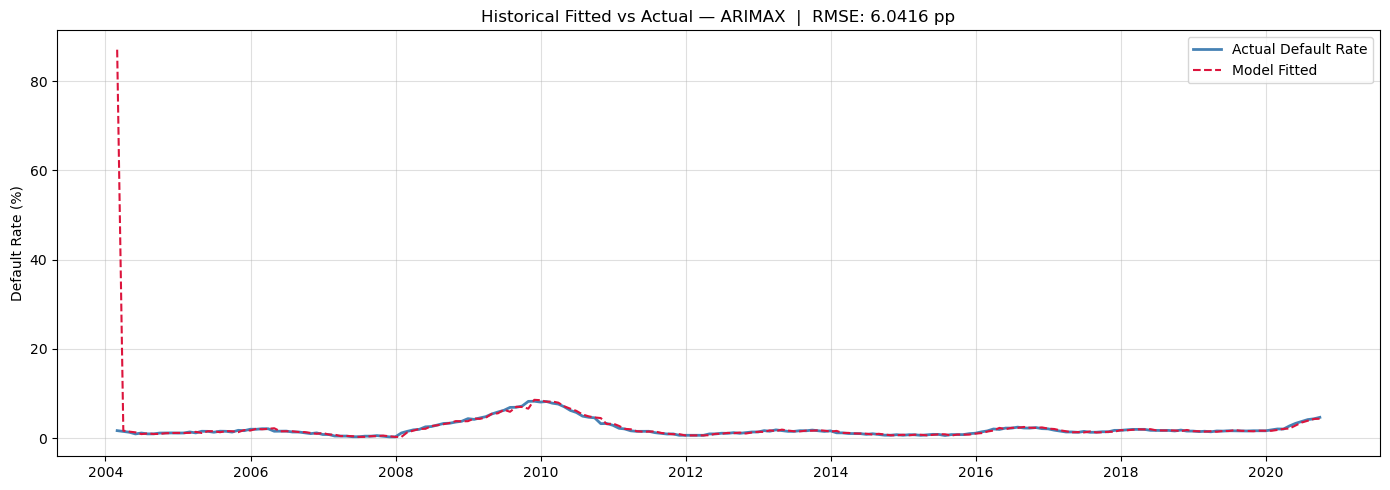

In [24]:
plt.figure(figsize=(14, 5))
plt.plot(actual_full.index, actual_full * 100, color='steelblue', linewidth=2, label='Actual Default Rate')
plt.plot(fitted.index,      fitted * 100,      color='crimson',   linewidth=1.5, linestyle='--', label='Model Fitted')
plt.title(f'Historical Fitted vs Actual — {best_key}  |  RMSE: {in_rmse*100:.4f} pp')
plt.ylabel('Default Rate (%)')
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

## 15. Forecast — September 30, 2021

We use the feature values as of **September 30, 2020** (last row in the dataset) and forecast 12 months ahead.

**Assumption:** All exogenous features held at their September 2020 levels (steady-state). This is the standard approach when future macro values are unknown.


In [25]:
# Feature values at the last observation (Sept 2020)
last_features = model_data[features].iloc[-1]
print("Feature values as of Sept 30, 2020:")
print(last_features.to_string())

Feature values as of Sept 30, 2020:
spread         26.370000
distress_l6     0.242508
lending_l6      0.000000
unemp_l6        5.800000
migrate_l3     -7.072215
vix            39.210000


In [26]:
# Build 12-month forecast horizon with features held constant
X_future = pd.DataFrame(
    [last_features.values] * 12,
    columns=features,
    index=pd.date_range(start='2020-10-31', periods=12, freq='M')
)


if best_key == 'OLS':
    forecast_log = final_model.predict(sm.add_constant(X_future, has_constant='add'))
else:
    forecast_log = final_model.forecast(steps=12, exog=X_future)

forecast_default = np.exp(forecast_log)

pred_sept_2021 = forecast_default.iloc[-1]
actual_sept_2020 = model_data['Default Rate'].iloc[-1]

print(f"Actual default rate (Sept 2020): {actual_sept_2020*100:.2f}%")
print(f"Forecast default rate (Sept 2021): {pred_sept_2021*100:.2f}%")
print(f"Implied change: {(pred_sept_2021 - actual_sept_2020)*100:+.2f} pp")

Actual default rate (Sept 2020): 4.64%
Forecast default rate (Sept 2021): 5.65%
Implied change: +1.01 pp


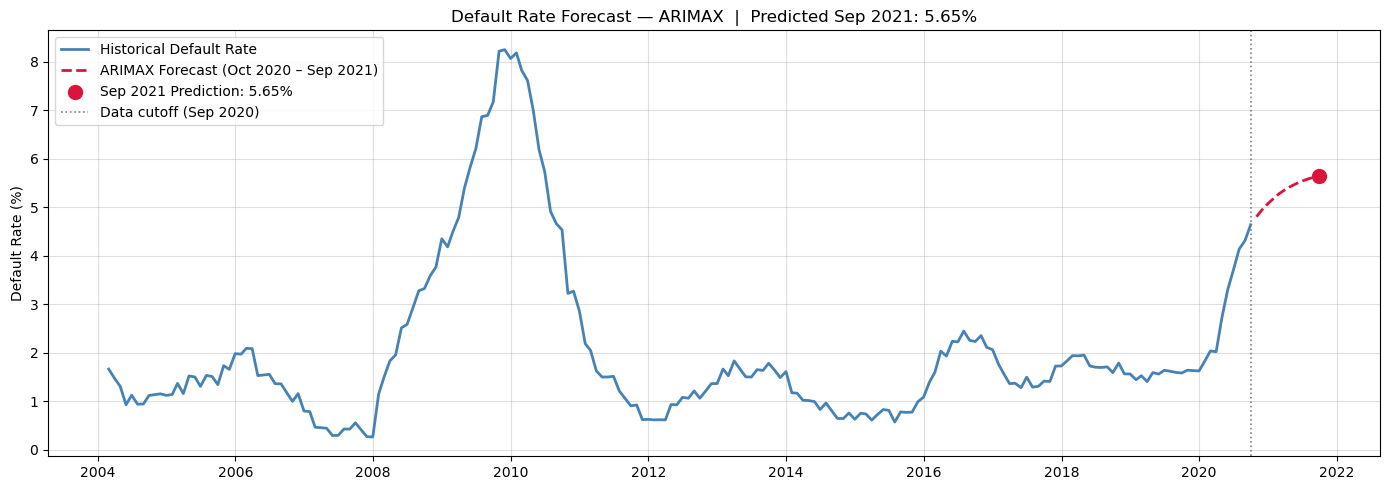

In [27]:
plt.figure(figsize=(14, 5))

# Historical
hist = model_data['Default Rate']
plt.plot(hist.index, hist * 100, color='steelblue', linewidth=2, label='Historical Default Rate')

# Forecast path
plt.plot(X_future.index, forecast_default * 100, color='crimson', linewidth=2,
         linestyle='--', label=f'{best_key} Forecast (Oct 2020 – Sep 2021)')

# Highlight the Sept 2021 point
plt.scatter([X_future.index[-1]], [pred_sept_2021 * 100], color='crimson', s=100, zorder=5,
            label=f'Sep 2021 Prediction: {pred_sept_2021*100:.2f}%')

plt.axvline(hist.index[-1], color='gray', linestyle=':', linewidth=1.2, label='Data cutoff (Sep 2020)')
plt.title(f'Default Rate Forecast — {best_key}  |  Predicted Sep 2021: {pred_sept_2021*100:.2f}%')
plt.ylabel('Default Rate (%)')
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

## 16. Summary

In [28]:
print("=" * 60)
print("  RESULTS SUMMARY")
print("=" * 60)
print(f"  Target variable : LTM Default Rate (Institutional Loans)")
print(f"  Forecast target : September 30, 2021")
print()
print("  Features used:")
for f in features:
    print(f"    - {f}")
print()
print("  Models compared:")
print(comparison[['Model', 'OOS RMSE']].to_string(index=False))
print()
print(f"  Final model     : {best_key}")
print(f"  Sept 2020 actual: {actual_sept_2020*100:.2f}%")
print(f"  Sept 2021 forecast: {pred_sept_2021*100:.2f}%")
print("=" * 60)

  RESULTS SUMMARY
  Target variable : LTM Default Rate (Institutional Loans)
  Forecast target : September 30, 2021

  Features used:
    - spread
    - distress_l6
    - lending_l6
    - unemp_l6
    - migrate_l3
    - vix

  Models compared:
             Model  OOS RMSE
      OLS Baseline  0.013588
     ARIMAX(1,1,1)  0.011180
SARIMAX(+seasonal)  0.011652

  Final model     : ARIMAX
  Sept 2020 actual: 4.64%
  Sept 2021 forecast: 5.65%
